In [2]:
import SimpleITK as sitk
import numpy as np
import pyvista as pv
import nibabel as nib
from matplotlib import pyplot as plt
from morphometry.femur import calculate_femoral_torsion
from morphometry.tibia import calculate_tibial_torsion
from morphometry.knee import calculate_knee_rotation_angle
from morphometry.whole_leg import calculate_mikulicz_deviation
from morphometry.ankle import calculate_pma_angle
from morphometry.hip import calculate_ccd
from morphometry import hip as h
from morphometry.image_io import Image

In [3]:
pv.set_jupyter_backend('trame')

In [4]:
# hip = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/t1_tse_tra_Huften_bds_10mm_PA000006.nii.gz')
# knee = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset002_AugsburgKnee/labelsTr/6: t1_tse_tra Knie PA000006.nii.gz')
# ankle = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset003_AugsburgAnkle/labelsTr/t1_tse_tra_OSG_PA000006.nii.gz')

In [5]:
# hip = sitk.ReadImage('/home/simon/Downloads/Augsburg/labels/huefte/t1_tse_tra_Huften_bds_PA000006.nii.gz')
# knee = sitk.ReadImage('/home/simon/Downloads/Augsburg/labels/knie/t1_tse_tra_Knie_PA000006.nii.gz')
# ankle = sitk.ReadImage('/home/simon/Downloads/Augsburg/labels/osg/t1_tse_tra_OSG_PA000006.nii.gz')
hip = Image('nibabel')
hip.read_image('/home/simon/Downloads/Augsburg/labels/huefte/t1_tse_tra_Huften_bds_PA000006.nii.gz')
knee = Image('nibabel')
knee.read_image('/home/simon/Downloads/Augsburg/labels/knie/t1_tse_tra_Knie_PA000006.nii.gz')
ankle = Image('nibabel')
ankle.read_image('/home/simon/Downloads/Augsburg/labels/osg/t1_tse_tra_OSG_PA000006.nii.gz')

In [38]:
hip = Image('nibabel')
hip.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000006/hip_seg.nii.gz')
knee = Image('nibabel')
knee.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000006/knee_seg.nii.gz')
ankle = Image('nibabel')
ankle.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000006/ankle_seg.nii.gz')

In [39]:
hip.transform_coordinate_system()
knee.transform_coordinate_system()
ankle.transform_coordinate_system()

In [40]:
hip.get_size(), knee.get_size(), ankle.get_size()

((30, 324, 384), (38, 324, 384), (32, 324, 384))

In [41]:
from morphometry.whole_leg import calculate_leg_length
calculate_leg_length(hip, ankle)

1043.6558281819318

In [42]:
np.min(np.argwhere(hip.get_array())[:, 0]), np.max(np.argwhere(ankle.get_array())[:, 0])

(0, 25)

In [43]:
hip.transform_index_to_physical_point((0, 0, 0)), hip.transform_index_to_physical_point((25, 0, 0))

(array([-214.57839966,  172.04644775,  781.23141479]),
 array([-214.57839966,  172.04644775,  531.23141479]))

In [44]:
np.min(np.argwhere(ankle.get_array())[:, 0]), np.max(np.argwhere(ankle.get_array())[:, 0])

(0, 25)

In [45]:
ankle.transform_index_to_physical_point((0, 0, 0)), ankle.transform_index_to_physical_point((25, 0, 0))

(array([-216.60809326,  175.94793701, -153.97125244]),
 array([-216.60809326,  175.94793701, -253.97125244]))

In [46]:
hip_mask = hip.get_array()
ankle_mask = ankle.get_array()
left_hip = hip_mask[:, :, :hip_mask.shape[2] // 2]
right_hip = hip_mask[:, :, hip_mask.shape[2] // 2:]
left_ankle = ankle_mask[:, :, :ankle_mask.shape[2] // 2]
right_ankle = ankle_mask[:, :, ankle_mask.shape[2] // 2:]

left_hip = nib.Nifti1Image(left_hip, hip.get_affine(), hip.get_header())
left_hip = Image(left_hip)
right_hip = nib.Nifti1Image(right_hip, hip.get_affine(), hip.get_header())
right_hip = Image(right_hip)
left_ankle = nib.Nifti1Image(left_ankle, ankle.get_affine(), ankle.get_header())
left_ankle = Image(left_ankle)
right_ankle = nib.Nifti1Image(right_ankle, ankle.get_affine(), ankle.get_header())
right_ankle = Image(right_ankle)

In [47]:
np.min(np.argwhere(left_hip.get_array())[:, 0]), np.max(np.argwhere(left_ankle.get_array())[:, 0])

(0, 25)

In [49]:
np.linalg.norm(left_hip.transform_index_to_physical_point((0, 0, 0)) - left_ankle.transform_index_to_physical_point((25, 0, 0)))

1035.2120089758237

In [50]:
calculate_leg_length(left_hip, left_ankle)

1043.3108609096942

In [16]:
x_ratio = abs(hip.GetSpacing()[2]) / 2 * abs(hip.GetSpacing()[0])
x_ratio

5.46875

In [7]:
# hip = correct_axis_ordering(hip)
# knee = correct_axis_ordering(knee)
# ankle = correct_axis_ordering(ankle)

In [9]:
hip.GetSize()

(384, 324, 19)

In [10]:
p1 = (0, 0, 0)
p2 = (0, 0, 19)
hip.TransformIndexToPhysicalPoint(p1), hip.TransformIndexToPhysicalPoint(p2)

((-204.32785034179688, -172.04644775390625, 671.2314453125),
 (-204.32785034179688, -172.04644775390625, 481.2314453125))

In [6]:
x_ratio = abs(hip.GetSpacing()[2]) / 2 * abs(hip.GetSpacing()[0])
x_ratio

5.46875

In [7]:
hip_np = sitk.GetArrayFromImage(hip)
knee_np = sitk.GetArrayFromImage(knee)
ankle_np = sitk.GetArrayFromImage(ankle)

In [59]:
hip.GetDirection(), knee.GetDirection(), ankle.GetDirection()

((1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0),
 (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0),
 (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0))

# Notes
Code expects:
- anterior - posterior : small - large
- superior - inferior : small - large
- left patient side - right image side and vice versa

This dataset:
- anterior - posterior : large - small for hip
- anterior - posterior : small - large for knee, ankle
- superior - inferior : large small for hip, knee, and ankle

-> flip x axis for hip, knee and ankle

-> flip y axis for hip

In [7]:
# Code expects superior - inferior axis to be low - high, i.e. 0 is the most proximal slice. 
# In Augsburg Dataset, this is oppsoite, so we flip the axis
hip_np = hip_np[::-1]
knee_np = knee_np[::-1]
ankle_np = ankle_np[::-1]
# Code also expects anterior - posterior axis to be low - high, i.e. 0 is the most anterior slice.
# In Augsburg Dataset, this is also opposite, so we flip the axis
hip_np = hip_np[:, ::-1]


In [60]:
hip_np.shape, knee_np.shape, ankle_np.shape

((19, 324, 384), (38, 324, 384), (29, 324, 384))

In [14]:
left_hip = hip_np[:, :, :hip_np.shape[2]//2]
right_hip = hip_np[:, :, hip_np.shape[2]//2:]

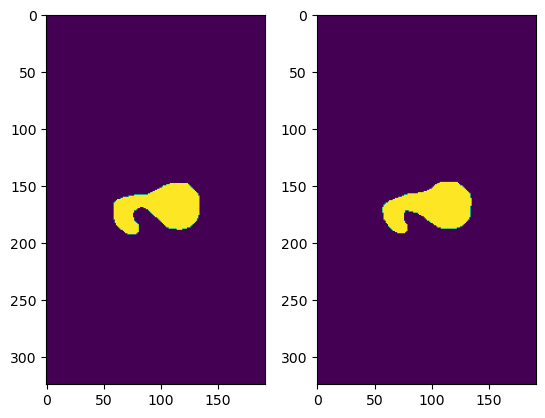

In [8]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(left_hip[7])
ax[1].imshow(right_hip[7][:, ::-1])
plt.show()

In [9]:
left_knee = knee_np[:, :, :knee_np.shape[2]//2]
right_knee = knee_np[:, :, knee_np.shape[2]//2:]

In [10]:
left_ankle = ankle_np[:, :, :ankle_np.shape[2]//2]
right_ankle = ankle_np[:, :, ankle_np.shape[2]//2:]

In [65]:
pv.PolyData(np.argwhere(left_hip) * np.array([x_ratio, 1, 1])).plot()

Widget(value='<iframe src="http://localhost:36955/index.html?ui=P_0x7003ee1a8070_4&reconnect=auto" class="pyvi…

In [66]:
import importlib
importlib.reload(h)
r, center = h.get_femoral_head_center(left_hip, side='left', segmentation_label=1, x_ratio=x_ratio)
pc = np.argwhere(left_hip).astype(np.float32)
pc[:, 0] *= x_ratio
p = pv.Plotter()
p.add_mesh(pv.PolyData(pc))
# p.add_mesh(pv.PolyData(pcu), color='red')
p.add_mesh(pv.Sphere(radius=r, center=center * [x_ratio, 1, 1]))
p.show()

Widget(value='<iframe src="http://localhost:36955/index.html?ui=P_0x7003f4b43820_5&reconnect=auto" class="pyvi…

In [67]:
center

array([  5.86336465, 166.78789573, 117.04658013])

(-10.474234828225853, <Figure size 640x480 with 2 Axes>)

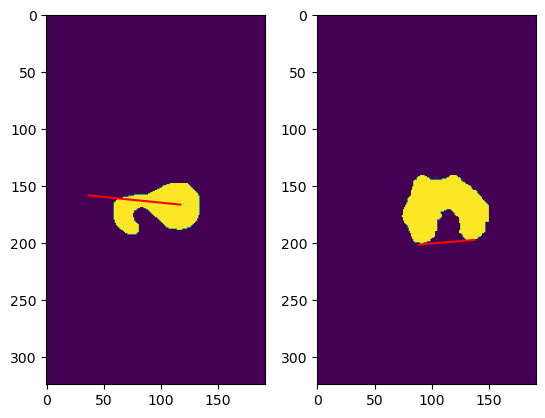

In [11]:
calculate_femoral_torsion(left_hip, left_knee, side='left', segmentation_label=1, x_ratio=x_ratio, plot=True)

(-3.1433904906442702, <Figure size 640x480 with 2 Axes>)

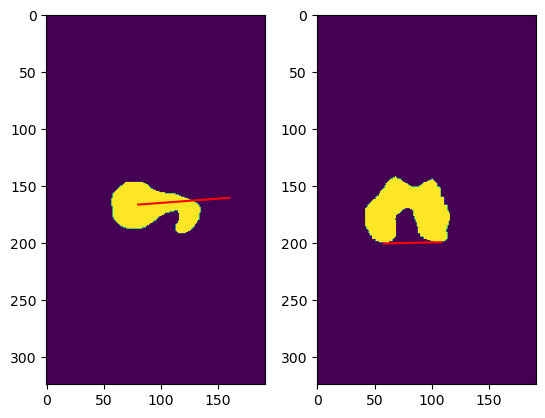

In [12]:
calculate_femoral_torsion(right_hip, right_knee, side='right', segmentation_label=1, x_ratio=x_ratio, plot=True)

(37.29799604305548, <Figure size 640x480 with 2 Axes>)

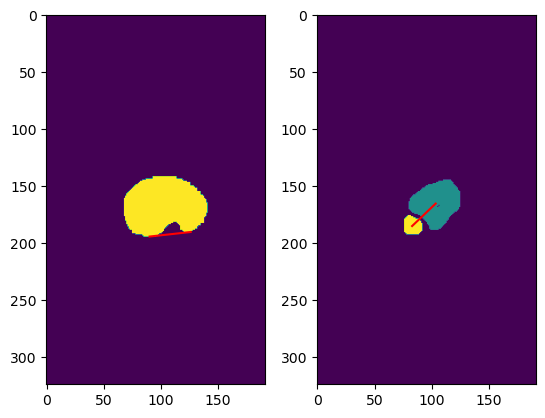

In [13]:
calculate_tibial_torsion(left_knee, left_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, plot=True)

(41.69581027528489, <Figure size 640x480 with 2 Axes>)

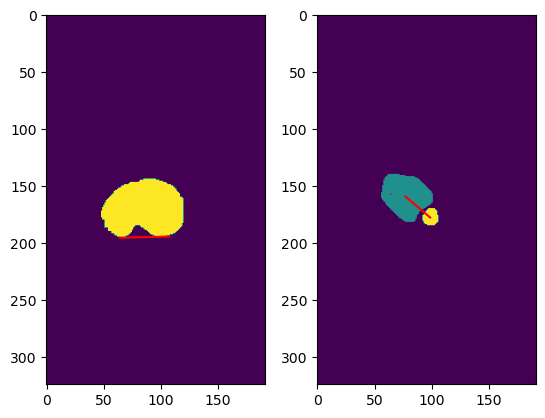

In [14]:
calculate_tibial_torsion(right_knee, right_ankle, tibia_label_knee=2, tibia_label_ankle=1, fibula_label=2, side='right', plot=True)

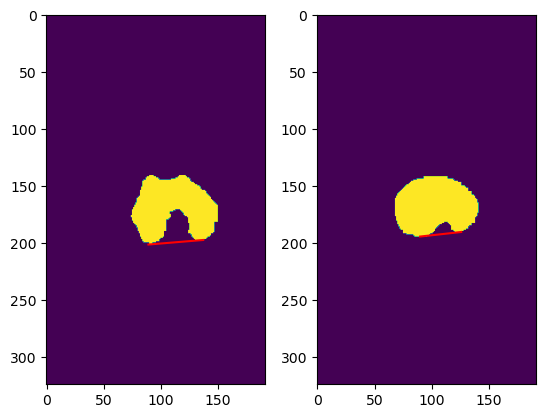

1.5765500551837375

In [72]:
calculate_knee_rotation_angle(left_knee, femur_label=1, tibia_label=2, plot=True)

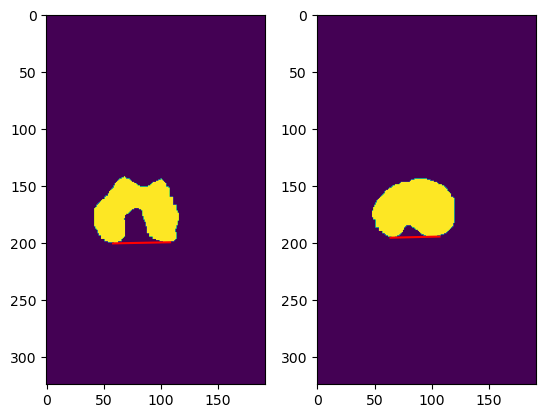

0.18645701569383197

In [73]:
calculate_knee_rotation_angle(right_knee, femur_label=1, tibia_label=2, plot=True)

In [47]:
calculate_mikulicz_deviation(left_hip, left_knee, left_ankle, hip, knee, ankle, side='left', x_ratio=x_ratio, hip_x_axis_flipped=True)

Multiple connected components found on layer with femoral head, choosing the largest one.
Femoral head center: [498.79494809   8.73977482 -64.94768986], Knee center: [184.91413817  -5.75609226 -82.93308218], Ankle center: [-182.98701142   21.3636724   -67.34224094]
Knee center is to the left image side of the Mikulicz line.


16.882877628390485

In [48]:
calculate_mikulicz_deviation(right_hip, right_knee, right_ankle, hip, knee, ankle, side='right', x_ratio=x_ratio, hip_x_axis_flipped=True)

Multiple connected components found on layer with femoral head, choosing the largest one.
Femoral head center: [ 505.07711392    8.70366848 -128.09849644], Knee center: [ 186.16293923   -0.73218806 -115.33313997], Ankle center: [-180.15670171   23.14694512 -123.94293106]
Knee center is to the left image side of the Mikulicz line.


10.83111861610054

In [49]:
calculate_pma_angle(left_ankle, 1, 2)

[ 12.         157.2231405  149.09090909] [ 16.  188.5 109.5]


141.46494229522992

In [50]:
calculate_pma_angle(right_ankle, 1, 2)

[ 12.         153.30434783  57.7826087 ] [ 14.         189.81081081  90.72972973]


47.97641394342753

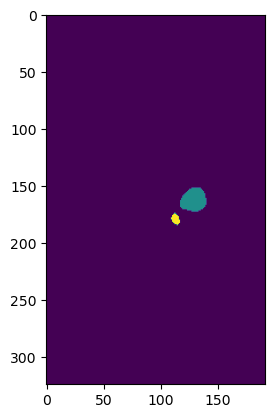

In [51]:
plt.imshow(left_ankle[0])

In [37]:
from morphometry.utils import calculate_angle_between_vectors

p1 = np.array([14, 62.5]) * np.array([x_ratio, 1])
p2 = np.array([18, 103.68]) * np.array([x_ratio, 1])
p1_p2 = p2 - p1

p3_p4 = np.array([0, 1])

calculate_angle_between_vectors(p1_p2, p3_p4)

27.977439779366723

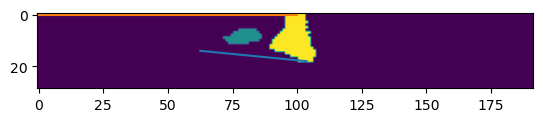

In [35]:
plt.imshow(right_ankle[:, 145])
plt.plot([p1[2], p2[2]], [p1[0] / x_ratio, p2[0] / x_ratio])
plt.plot([0, 100], [0, 0])
plt.show()

In [12]:
calculate_ccd(left_hip, 'left', 1, False, x_ratio, debug=True)

Femoral head center: [  5.1271372  167.17546667 113.69875324], femoral neck center: [ 10.76832144 167.7252817   93.57476548], femoral shaft axis: (array([ 17, 165,  91]), array([ 12, 173,  88]))


(100.17571577384437, 126.49722943870086)

In [13]:
calculate_ccd(right_hip, 'right', 1, False, x_ratio, debug=True)

Femoral head center: [  5.53650457 167.10903499  81.00609708], femoral neck center: [ 11.30235394 167.78819702 101.0146041 ], femoral shaft axis: (array([ 17, 165,  98]), array([ 12, 171, 103]))


(112.93468672834662, 91.92851324682044)

In [18]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(left_hip) * np.array([x_ratio, 1, 1])))
p.add_lines(np.array([[5 * x_ratio, 167, 113], [11 * x_ratio, 167, 93]]), color='red')
p.add_lines(np.array([[12 * x_ratio, 173, 88], [17 * x_ratio, 165, 91]]), color='green')
p.show()

Widget(value='<iframe src="http://localhost:37575/index.html?ui=P_0x7973769b5b10_4&reconnect=auto" class="pyvi…

In [19]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(right_hip) * np.array([x_ratio, 1, 1])))
p.add_lines(np.array([[5 * x_ratio, 167, 81], [11 * x_ratio, 167, 101]]), color='red')
p.add_lines(np.array([[12 * x_ratio, 171, 103], [17 * x_ratio, 165, 98]]), color='green')
p.show()

Widget(value='<iframe src="http://localhost:37575/index.html?ui=P_0x7973769b7730_5&reconnect=auto" class="pyvi…

In [19]:
a = np.array([0, 10, 31])
n = np.array([12, 17, 19])
p = np.array([13, 21, 5])

In [22]:
np.linalg.norm((a - p) - ((a - p) * n) * n), np.linalg.norm((a - p) - np.dot(np.dot(a - p, n), n)), np.linalg.norm(np.cross(a - p, n)) / np.linalg.norm(n)

(10054.934360800175, 4249.630336864608, 30.61508411412357)

In [15]:
np.array([2, 2]) * np.array([2, 2]), np.dot(np.array([2, 2]), np.array([2, 2]))

(array([4, 4]), 8)

# SSM

In [1]:
import numpy as np
import SimpleITK as sitk
import pyssam
from pathlib import Path
import point_cloud_utils as pcu
from tqdm import tqdm

In [2]:
n_points = np.empty(len([1 for _ in Path('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/').iterdir()]))
print(n_points.shape)
for i, patient in enumerate(Path('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/').iterdir()):
    image = sitk.ReadImage(str(patient))
    array = sitk.GetArrayFromImage(image)
    points = np.argwhere(array)
    print(points.shape)
    n_points[i] = points.shape[0]
    

(72,)
(14926, 3)
(21261, 3)
(14905, 3)
(21584, 3)
(28934, 3)
(10251, 3)
(19742, 3)
(14545, 3)
(17110, 3)
(14910, 3)
(31080, 3)
(35454, 3)
(28912, 3)
(22993, 3)
(21324, 3)
(15262, 3)
(14112, 3)
(12719, 3)
(13823, 3)
(21825, 3)
(17226, 3)
(21793, 3)
(25417, 3)
(12181, 3)
(19384, 3)
(16629, 3)
(26697, 3)
(24214, 3)
(17396, 3)
(24726, 3)
(24398, 3)
(21004, 3)
(19438, 3)
(19171, 3)
(18716, 3)
(25555, 3)
(23517, 3)
(11471, 3)
(22976, 3)
(7340, 3)
(20430, 3)
(14151, 3)
(37747, 3)
(20494, 3)
(21869, 3)
(17198, 3)
(17696, 3)
(10929, 3)
(22392, 3)
(30347, 3)
(15626, 3)
(26523, 3)
(19998, 3)
(14284, 3)
(14199, 3)
(21735, 3)
(17868, 3)
(22295, 3)
(12649, 3)
(21512, 3)
(21584, 3)
(20273, 3)
(23091, 3)
(11937, 3)
(23037, 3)
(15544, 3)
(30290, 3)
(19274, 3)
(11269, 3)
(21152, 3)
(32426, 3)
(19230, 3)


In [33]:
array.shape

(12, 324, 384)

In [34]:
a = np.ones((15, 324, 192))
b = np.ones((15, 324, 192))
c = np.concatenate((a, b), 2)
c.shape

(15, 324, 384)

In [25]:
n_points.min()

7340.0

In [40]:
landmarks = np.empty((n_points.shape[0], int(n_points.min()), 3))
rng = np.random.default_rng()
for i, patient in enumerate(Path('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/').iterdir()):
    image = sitk.ReadImage(str(patient))
    array = sitk.GetArrayFromImage(image)
    points = np.argwhere(array).astype(np.float32)
    sample = rng.choice(points, int(n_points.min()), replace=False)
    landmarks[i] = sample


In [41]:
ssm = pyssam.SSM(landmarks)

In [47]:
ssm.create_pca_model(ssm.landmarks_columns_scale)
mean_shape = ssm.compute_dataset_mean().reshape(-1, 3)

In [50]:
mean_shape

array([[-0.0032388 ,  0.0047438 ,  0.01336153],
       [-0.00186104,  0.0138421 , -0.14839348],
       [-0.00936607, -0.00925688,  0.18545475],
       ...,
       [ 0.0062567 , -0.0254483 , -0.11245716],
       [ 0.00136049, -0.00250753, -0.27884058],
       [-0.01498137,  0.03147082,  0.07231392]])